In [2]:
import sys
from pathlib import Path

# Find project root dynamically
def get_project_root() -> Path:
    try:
        path = Path(__file__).resolve()
        for parent in [path] + list(path.parents):
            if (parent / "requirements.txt").exists() or (parent / "project").exists():
                return parent
    except NameError:
        pass
    path = Path.cwd().resolve()
    for parent in [path] + list(path.parents):
        if (parent / "requirements.txt").exists() or (parent / "project").exists():
            return parent
    return path

ROOT = get_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
class InfoNCELoss(nn.Module):
    def __init__(self, init_temperature=0.07):
        """
        Args:
            init_temperature: Initial value of tau.
                              CLIP initializes tau around 0.07.
        """
        super().__init__()

        # Learn log(1/tau) instead of tau itself.
        # This guarantees tau always remains positive after exponentiation.
        self.log_inv_tau = nn.Parameter(
            torch.tensor([1.0 / init_temperature]).log()
        )

    def forward(self, image_embeds, text_embeds):
        """
        Args:
            image_embeds : (B, D)
            text_embeds  : (B, D)

        Returns:
            Symmetric InfoNCE loss.
        """

        # Step 1: L2-normalize embeddings
        # Makes dot product equal cosine similarity.
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)

        # Step 2: Compute inverse temperature
        # Clamp log_inv_tau for numerical stability.
        # log(100) ≈ 4.6052
        log_inv_tau = self.log_inv_tau.clamp(0, 4.6052)
        inv_tau = log_inv_tau.exp()

        # Step 3: Similarity matrix
        # image_embeds : (B, D)
        # text_embeds.T: (D, B)
        # logits       : (B, B)
        # logits[i][j] =
        # cosine_similarity(image_i, text_j) / tau
        logits = inv_tau * (image_embeds @ text_embeds.T)

        # Step 4: Ground-truth labels
        # Correct pairs lie along the diagonal.
        # labels = [0,1,2,...,B-1]
        batch_size = image_embeds.size(0)
        labels = torch.arange(batch_size, device=logits.device)

        # Step 5: Image -> Text loss
        # Each image should retrieve its matching caption.
        loss_i2t = F.cross_entropy(logits, labels)

        # Step 6: Text -> Image loss
        # Each caption should retrieve its matching image.
        loss_t2i = F.cross_entropy(logits.T, labels)

        # Step 7: Symmetric CLIP loss
        loss = (loss_i2t + loss_t2i) / 2

        return loss

In [4]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 32
feature_dim = 192
projection_dim = 128

steps = 500
lr = 1e-3

In [5]:
image_features = torch.randn(
    batch_size,
    feature_dim,
    device=device
)

text_features = torch.randn(
    batch_size,
    feature_dim,
    device=device
)

In [6]:
image_proj = nn.Linear(
    feature_dim,
    projection_dim,
    bias=False
).to(device)

text_proj = nn.Linear(
    feature_dim,
    projection_dim,
    bias=False
).to(device)

In [7]:
loss_fn = InfoNCELoss().to(device)

optimizer = optim.Adam(
    list(image_proj.parameters()) +
    list(text_proj.parameters()) +
    list(loss_fn.parameters()),
    lr=lr
)

In [8]:
import torch.nn.functional as F

losses = []

for step in range(steps):

    optimizer.zero_grad()

    image_embeds = image_proj(image_features)
    text_embeds = text_proj(text_features)

    loss = loss_fn(
        image_embeds,
        text_embeds
    )

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (step + 1) % 50 == 0:
        print(
            f"Step {step+1:3d} | Loss = {loss.item():.4f}"
        )

Step  50 | Loss = 0.0004
Step 100 | Loss = 0.0003
Step 150 | Loss = 0.0003
Step 200 | Loss = 0.0003
Step 250 | Loss = 0.0002
Step 300 | Loss = 0.0002
Step 350 | Loss = 0.0002
Step 400 | Loss = 0.0002
Step 450 | Loss = 0.0002
Step 500 | Loss = 0.0001


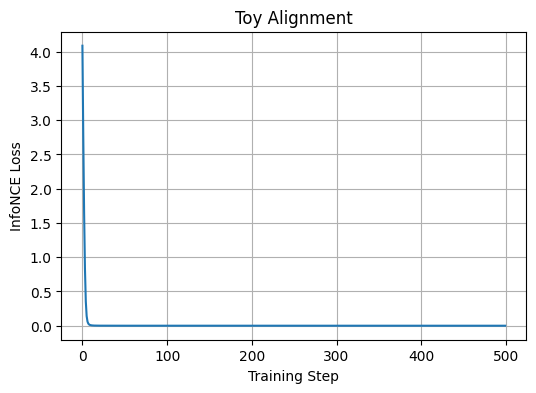

In [9]:
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("InfoNCE Loss")
plt.title("Toy Alignment")
plt.grid(True)
plt.show()

In [10]:
with torch.no_grad():

    img = nn.functional.normalize(
        image_proj(image_features),
        dim=-1
    )

    txt = nn.functional.normalize(
        text_proj(text_features),
        dim=-1
    )

    similarity = img @ txt.T

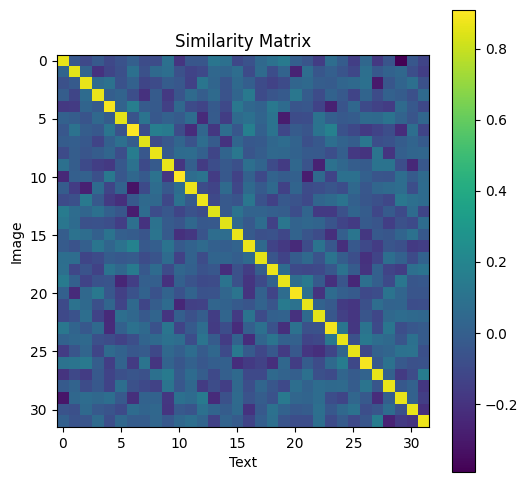

In [11]:
plt.figure(figsize=(6,6))
plt.imshow(similarity.cpu(), cmap="viridis")
plt.colorbar()
plt.title("Similarity Matrix")
plt.xlabel("Text")
plt.ylabel("Image")
plt.show()

In [12]:
predictions = similarity.argmax(dim=1)

labels = torch.arange(batch_size, device=device)

accuracy = (predictions == labels).float().mean()

print(f"Retrieval Accuracy: {accuracy.item()*100:.2f}%")

Retrieval Accuracy: 100.00%


In [13]:
# Average diagonal similarity
diag_mean = similarity.diag().mean().item()

# Average off-diagonal similarity
mask = ~torch.eye(
    similarity.size(0),
    dtype=torch.bool,
    device=similarity.device
)

off_diag_mean = similarity[mask].mean().item()

print(f"Average Diagonal Similarity     : {diag_mean:.4f}")
print(f"Average Off-Diagonal Similarity : {off_diag_mean:.4f}")

Average Diagonal Similarity     : 0.8692
Average Off-Diagonal Similarity : -0.0269
